<a href="https://colab.research.google.com/github/josidimufrj/geo_modelagem/blob/main/Parte1_Cartopy__opernicus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 1 – Mapeamento climático da região produtora de açaí

mapa do Estado do Pará utilizando a biblioteca Cartopy em Python. No mapa, deverá ser destacada a principal região produtora de açaí, considerando municípios como Igarapé-Miri, Cametá, Abaetetuba e entorno.

In [ ]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 27.7 MB/s eta 0:00:00


In [ ]:
!pip install matplotlib-scalebar

/tmp/ipykernel_1290/286903552.py:70: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='lower left', fontsize=10)


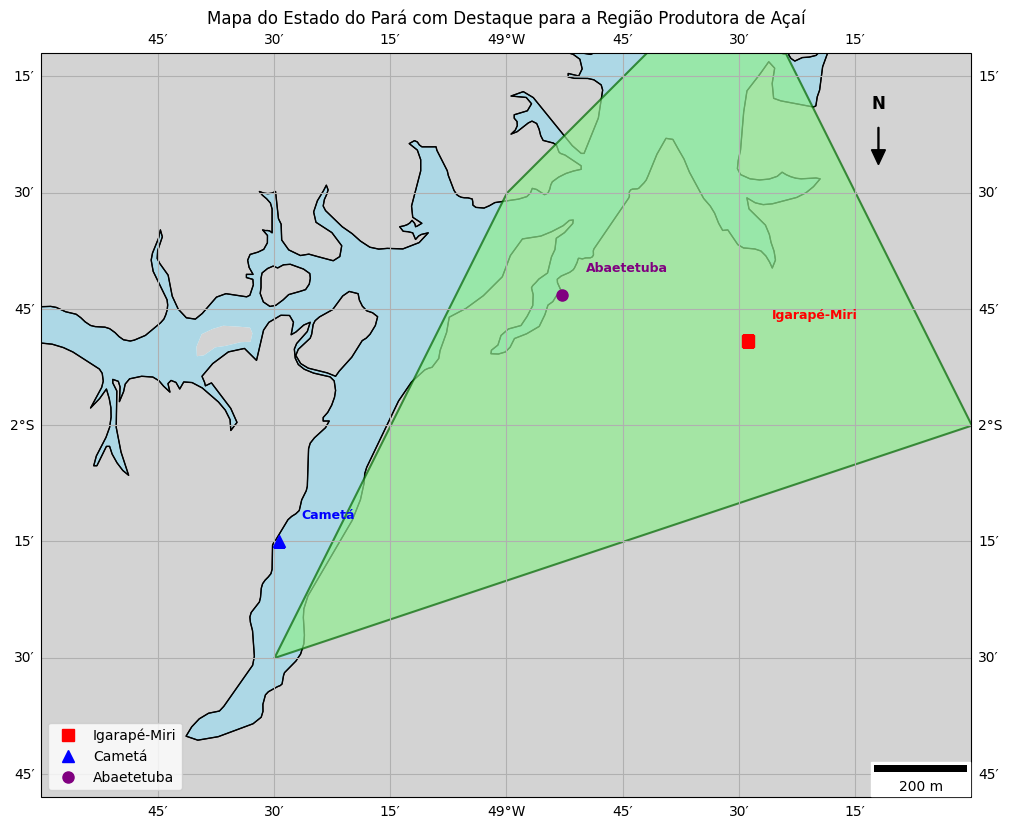

In [ ]:
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from shapely.geometry import Polygon # Para definir a região do açaí
from matplotlib_scalebar.scalebar import ScaleBar # Importa ScaleBar

fig = plt.figure(figsize=(12, 10)) # Aumenta o tamanho da figura para melhor visualização
ax = plt.axes(projection=ccrs.PlateCarree()) # Projeção de Plate Carrée

# 🌍 Adiciona características geográficas
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.coastlines(resolution='10m', linewidth=0.8) # Fronteiras costeiras
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', linewidth=0.5) # Fronteiras de países
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='black', linewidth=1.0) # Fronteiras de estados (Brasil) - Aumentado o destaque

# Define a extensão do mapa para focar na região produtora de açaí e municípios
# Coordenadas ajustadas para um foco mais apertado na região de interesse
ax.set_extent([-50.0, -48.0, -2.8, -1.2], crs=ccrs.PlateCarree())

# Adiciona linhas de grade para coordenadas
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Define a região produtora de açaí (aproximando com um polígono)
# Coordenadas dos municípios mencionados e entorno para formar um polígono
acai_region_coords = [
    (-49.5, -2.5), # Sudoeste de Cametá
    (-48.0, -2.0), # Sudeste de Igarapé-Miri
    (-48.5, -1.0), # Norte de Igarapé-Miri / Abaetetuba
    (-49.0, -1.5), # Noroeste de Abaetetuba
    (-49.5, -2.5)  # Fecha o polígono
]
acai_polygon = Polygon(acai_region_coords)

# Destaca a região do açaí com um polígono verde
ax.add_geometries([acai_polygon], ccrs.PlateCarree(),
                  facecolor='lightgreen', edgecolor='darkgreen', alpha=0.7,
                  linewidth=1.5, label='Principal Região Produtora de Açaí')

# Adiciona marcadores para os municípios específicos em cores diferentes
# Igarapé-Miri
ax.plot(-48.48, -1.82, 's', color='red', markersize=8, transform=ccrs.PlateCarree(), label='Igarapé-Miri')
ax.text(-48.48 + 0.05, -1.82 + 0.05, 'Igarapé-Miri', transform=ccrs.PlateCarree(), color='red', fontsize=9, fontweight='bold')

# Cametá
ax.plot(-49.49, -2.25, '^', color='blue', markersize=8, transform=ccrs.PlateCarree(), label='Cametá')
ax.text(-49.49 + 0.05, -2.25 + 0.05, 'Cametá', transform=ccrs.PlateCarree(), color='blue', fontsize=9, fontweight='bold')

# Abaetetuba
ax.plot(-48.88, -1.72, 'o', color='purple', markersize=8, transform=ccrs.PlateCarree(), label='Abaetetuba')
ax.text(-48.88 + 0.05, -1.72 + 0.05, 'Abaetetuba', transform=ccrs.PlateCarree(), color='purple', fontsize=9, fontweight='bold')

# Adiciona a escala gráfica
# É importante definir a unidade correta (e.g., 'km' para quilômetros)
scalebar = ScaleBar(1, 'km', location='lower right',
                    frameon=True,
                    color='black',
                    box_color='white')
ax.add_artist(scalebar)

# Adiciona a rosa dos ventos
# Posição aproximada para o canto superior direito
x_north, y_north = 0.9, 0.9 # Coordenadas relativas aos eixos (0 a 1)
ax.text(x_north, y_north + 0.02, 'N', transform=ax.transAxes, ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
ax.arrow(x_north, y_north, 0, -0.05, transform=ax.transAxes, length_includes_head=True,
         head_width=0.015, head_length=0.02, fc='black', ec='black')

plt.title("Mapa do Estado do Pará com Destaque para a Região Produtora de Açaí")
# Ajusta a legenda para não sobrepor a rosa dos ventos ou a escala
plt.legend(loc='lower left', fontsize=10)
plt.show()

# Dados meteorológicos

In [12]:
%pip install cdsapi


In [14]:
import cdsapi

dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": [
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "2m_dewpoint_temperature",
        "2m_temperature",
        "total_precipitation"
    ],
    "year": ["2024"],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "time": ["15:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [-1, -50.9, -2.8, -48]
\}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key='3ef2f54f-55b5-4bc3-a62a-b1ed4e74538c')
client.retrieve(dataset, request).download()


[ ]

[15]
1s
import xarray as xr
import pandas as pd

[16]
from google.colab import drive
drive.mount('/content/drive')
Produtos pagos do Colab - Cancelar contratos
$0
        "31"
    ],
    "time": ["15:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [-1, -50.9, -2.8, -48]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key='3ef2f54f-55b5-4bc3-a62a-b1ed4e74538c')
client.retrieve(dataset, request).download()


2026-07-07 19:59:48,704 INFO Request ID is df35d138-3637-4087-acde-10e7b1834685
INFO:ecmwf.datastores.legacy_client:Request ID is df35d138-3637-4087-acde-10e7b1834685
2026-07-07 19:59:49,102 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-07 20:00:02,650 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-07 20:01:45,454 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


154337dab6104b3fa3873bd6f448a060.zip:   0%|          | 0.00/446k [00:00<?, ?B/s]

'154337dab6104b3fa3873bd6f448a060.zip'

In [15]:
import xarray as xr
import pandas as pd

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
df = xr.open_dataset('/content/drive/MyDrive/Colab Notebooks/geomodelagem/dados_meteo_prod_acai_PA/data_stream-oper_stepType-accum.nc',engine='h5netcdf')
df.to_dataframe().reset_index()

,valid_time,latitude,longitude,tp,number,expver
0,2024-01-01 15:00:00,-1.00,-50.75,0.000054,0,0001
1,2024-01-01 15:00:00,-1.00,-50.50,0.000067,0,0001
2,2024-01-01 15:00:00,-1.00,-50.25,0.000093,0,0001
3,2024-01-01 15:00:00,-1.00,-50.00,0.000078,0,0001
4,2024-01-01 15:00:00,-1.00,-49.75,0.000066,0,0001
...,...,...,...,...,...,...
35131,2024-12-31 15:00:00,-2.75,-49.00,0.000074,0,0001
35132,2024-12-31 15:00:00,-2.75,-48.75,0.000094,0,0001
35133,2024-12-31 15:00:00,-2.75,-48.50,0.000181,0,0001
35134,2024-12-31 15:00:00,-2.75,-48.25,0.000152,0,0001
